<a href="https://colab.research.google.com/github/LuisManuelCatzoliSoriano/Procesos-Estoc-sticos/blob/main/DCanonica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Descomposición canónica

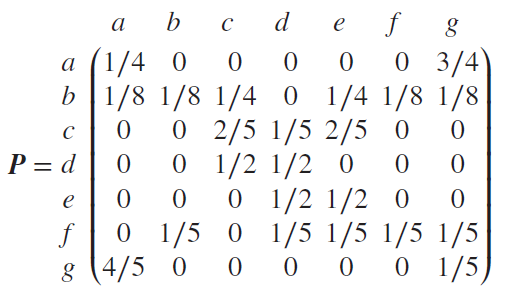

In [1]:
import numpy as np
import sympy as sp

1. Escriba la matriz $P$ de la imagen anexa y dibuje su diagrama de transiciones.

In [2]:
P = sp.Matrix([
    [1/4, 0, 0, 0, 0, 0, 3/4],
    [1/8, 1/8, 1/4, 0, 1/4, 1/8, 1/8],
    [0, 0, 2/5, 1/5, 2/5, 0, 0],
    [0, 0, 1/2, 1/2, 0, 0, 0],
    [0, 0, 0, 1/2, 1/2, 0, 0],
    [0, 1/5, 0, 1/5, 1/5, 1/5, 1/5],
    [4/5, 0, 0, 0, 0, 0, 1/5]
])
P

Matrix([
[ 0.25,     0,    0,   0,    0,     0,  0.75],
[0.125, 0.125, 0.25,   0, 0.25, 0.125, 0.125],
[    0,     0,  0.4, 0.2,  0.4,     0,     0],
[    0,     0,  0.5, 0.5,    0,     0,     0],
[    0,     0,    0, 0.5,  0.5,     0,     0],
[    0,   0.2,    0, 0.2,  0.2,   0.2,   0.2],
[  0.8,     0,    0,   0,    0,     0,   0.2]])

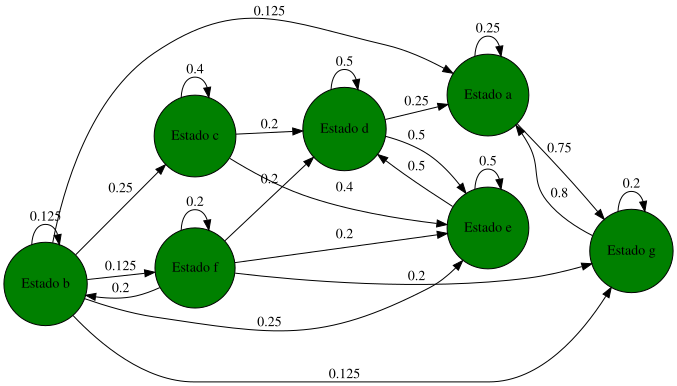

In [3]:
import networkx as nx
import graphviz

dot = graphviz.Digraph()
dot.attr(rankdir='LR')  # Se dibuja de izquierda a derecha

# Estilo nodos
dot.attr('node', shape='circle', style='filled',
         fillcolor='green', fontsize='14')

# Estados
dot.node('E1', 'Estado a')
dot.node('E2', 'Estado b')
dot.node('E3', 'Estado c')
dot.node('E4', 'Estado d')
dot.node('E5', 'Estado e')
dot.node('E6', 'Estado f')
dot.node('E7', 'Estado g')

# Transiciones
transiciones = [
    ('E1','E1','0.25'),
    ('E1','E2','0'),
    ('E1','E3','0'),
    ('E1','E4','0'),
    ('E1','E5','0'),
    ('E1','E6','0'),
    ('E1','E7','0.75'),
    ('E2','E1','0.125'),
    ('E2','E2','0.125'),
    ('E2','E3','0.25'),
    ('E2','E4','0'),
    ('E2','E5','0.25'),
    ('E2','E6','0.125'),
    ('E2','E7','0.125'),
    ('E3','E1','0'),
    ('E3','E2','0'),
    ('E3','E3','0.4'),
    ('E3','E4','0.2'),
    ('E3','E5','0.4'),
    ('E3','E6','0'),
    ('E3','E7','0'),
    ('E4','E1','0.25'),
    ('E4','E2','0'),
    ('E4','E3','0'),
    ('E4','E4','0.5'),
    ('E4','E5','0.5'),
    ('E4','E6','0'),
    ('E4','E7','0'),
    ('E5','E1','0'),
    ('E5','E2','0'),
    ('E5','E3','0'),
    ('E5','E4','0.5'),
    ('E5','E5','0.5'),
    ('E5','E6','0'),
    ('E5','E7','0'),
    ('E6','E1','0'),
    ('E6','E2','0.2'),
    ('E6','E3','0'),
    ('E6','E4','0.2'),
    ('E6','E5','0.2'),
    ('E6','E6','0.2'),
    ('E6','E7','0.2'),
    ('E7','E1','0.8'),
    ('E7','E2','0'),
    ('E7','E3','0'),
    ('E7','E4','0'),
    ('E7','E5','0'),
    ('E7','E6','0'),
    ('E7','E7','0.2'),
]


# Para que los nodos con probabilidad 0 no se muestren
for origen, destino, prob in transiciones:
    if prob != '0':
        dot.edge(origen, destino, label=prob)

dot

2. Determine si la matriz tiene o no distribución límite.

Primero se debe verificar que la matriz sea regular:

In [ ]:
P**10

Matrix([
[0.517354654010254,                   0,                 0,                 0,                 0,                   0, 0.482645345989746],
[0.171988654922658, 5.05661934518814e-6, 0.222173673923512, 0.266708044001801, 0.177778206582227, 5.05661934518814e-6, 0.161341307331112],
[                0,                   0,      0.3333117166,      0.4000406558,      0.2666476276,                   0,                 0],
[                0,                   0,      0.3333095345,      0.3999736235,       0.266716842,                   0,                 0],
[                0,                   0,      0.3333960525,       0.399988745,      0.2666152025,                   0,                 0],
[  0.1724017220618, 8.09059095230103e-6,  0.22220883367762, 0.266664125602881, 0.177782919931563, 8.09059095230103e-6, 0.160926217544232],
[0.514821702389063,                   0,                 0,                 0,                 0,                   0, 0.485178297610938]])

In [ ]:
P**11

Matrix([
[0.515454940294361,                   0,                 0,                 0,                 0,                   0,  0.48454505970564],
[0.172070841672972, 1.64340128718615e-6, 0.222224755725142, 0.266678871400585, 0.177760848339224, 1.64340128718615e-6, 0.161261396059503],
[                0,                   0,     0.33334501454,     0.40000648502,     0.26664850044,                   0,                 0],
[                0,                   0,     0.33331062555,     0.40000713965,      0.2666822348,                   0,                 0],
[                0,                   0,      0.3333527935,     0.39998118425,     0.26666602225,                   0,                 0],
[0.171842415874704, 2.62944205949783e-6, 0.222217618920227, 0.266666907620936, 0.177778634202758, 2.62944205949783e-6, 0.161489164497256],
[0.516848063686016,                   0,                 0,                 0,                 0,                   0, 0.483151936313985]])

Si al elevar la matriz a dos potencias sucesivas los ceros se mantienen en la misma posición, entonces la matriz no es regular. En este caso vemos que los ceros no cambian de posición, entonces no es regular la matriz.

Posteriormente haremos el análisis de las clases de los estados que son accesibles, se comunican y de las clases de comunicación.

3. Escriba la descomposición canónica de la matriz, determine el límite de la potencia n-esima y compare contra las distribuciones límite de las submatrices.


Accesibles:

Para $a$:   

$a \to a$

$a \to g$

Para $b$:   

$b \to a$

$b \to b$

$b \to c$

$b \to e$

$b \to f$

$b \to g$

Para $c$:   

$c \to c$

$c \to d$

$c \to e$

Para $d$:   

$d \to c$

$d \to d$

Para $e$:   

$e \to d$

$e \to e$

Para $f$:    

$f \to b$

$f \to d$

$f \to e$

$f \to f$

$f \to g$

Para $g$:   

$g \to a$

$g \to g$

Se comunican:

$a \leftrightarrow a$

$a \leftrightarrow g$

$b \leftrightarrow b$

$b \leftrightarrow f$

$c \leftrightarrow c$

$c \leftrightarrow d$

$d \leftrightarrow d$

$e \leftrightarrow e$

$f \leftrightarrow f$

$g \leftrightarrow g$

Clases de comunicación:

$\left\{b,f \right\}$, $\left\{ a,g \right\}$ y $\left\{ c,d,e \right\}$.

La clasificación de las clases anteriores:

$\left\{b,f \right\}$ es transitoria, $\left\{ a,g \right\}$ y $\left\{ c,d,e \right\}$ son recurrentes y cerradas.

De las clases de comunicación podemos decir que la cadena no es irreducible, por lo tanto, no tiene una única distribución límite global.

Con lo anterior se puede reescribir la matriz:

In [4]:
Pb = sp.Matrix([
    [1/8, 1/8, 1/8, 1/8, 1/4, 0, 1/4],
    [1/5, 1/5, 0, 1/5, 0, 1/5, 1/5],
    [0, 0, 1/4, 3/4, 0, 0, 0],
    [0, 0, 4/5, 1/5, 0, 0, 0],
    [0, 0, 0, 0, 2/5, 1/5, 2/5],
    [0, 0, 0, 0, 1/2, 1/2, 0],
    [0, 0, 0, 0, 0, 1/2, 1/2]
])
Pb

Matrix([
[0.125, 0.125, 0.125, 0.125, 0.25,   0, 0.25],
[  0.2,   0.2,     0,   0.2,    0, 0.2,  0.2],
[    0,     0,  0.25,  0.75,    0,   0,    0],
[    0,     0,   0.8,   0.2,    0,   0,    0],
[    0,     0,     0,     0,  0.4, 0.2,  0.4],
[    0,     0,     0,     0,  0.5, 0.5,    0],
[    0,     0,     0,     0,    0, 0.5,  0.5]])

De lo anterior, tenemos la descomposición canónica:

Submatriz de estados transitorios $b,f$:

In [6]:
P1 = sp.Matrix([
    [1/8, 1/8],
    [1/5, 1/5]
])
P1

Matrix([
[0.125, 0.125],
[  0.2,   0.2]])

Submatriz de transitorios a clases cerradas, estados $a,g,c,d,e$:

In [14]:
P2 = sp.Matrix([
    [1/8, 1/8, 1/8, 1/8, 1/4, 0, 1/4],
    [1/5, 1/5, 0, 1/5, 0, 1/5, 1/5],
])
P2

Matrix([
[0.125, 0.125, 0.125, 0.125, 0.25,   0, 0.25],
[  0.2,   0.2,     0,   0.2,    0, 0.2,  0.2]])

Submatriz de clases cerradas:

Para la clase $a,g$:

In [8]:
P3 = sp.Matrix([
    [1/4, 3/4],
    [4/5, 1/5]
])
P3

Matrix([
[0.25, 0.75],
[ 0.8,  0.2]])

Calculamos su distribución estacionaria:

In [54]:
x, y, z = sp.symbols('x y z')
v=sp.Matrix([[x],[y]])

In [56]:
ec1 =P3.col(0).dot(v)
ec2 =P3.col(1).dot(v)

In [57]:
e1=sp.Eq(ec1, x)
e2=sp.Eq(ec2, y)
e3=sp.Eq(x+y,1)

In [58]:
p1=sp.solve((e1,e2, e3), (x,y))
p1

{x: 0.516129032258065, y: 0.483870967741935}

Para la clase $c,d,e$:

In [9]:
P4 = sp.Matrix([
    [2/5, 1/5, 2/5],
    [1/2, 1/2, 0],
    [0, 1/2, 1/2]
])
P4

Matrix([
[0.4, 0.2, 0.4],
[0.5, 0.5,   0],
[  0, 0.5, 0.5]])

Calculamos su distribución estacionaria:

In [60]:
v1=sp.Matrix([[x],[y],[z]])

In [61]:
ec11 =P4.col(0).dot(v1)
ec21 =P4.col(1).dot(v1)
ec31 =P4.col(2).dot(v1)

In [62]:
e1=sp.Eq(ec11, x)
e2=sp.Eq(ec21, y)
e3=sp.Eq(ec31, z)
e4=sp.Eq(x+y+z,1)

In [63]:
p2=sp.solve((e2,e3, e4), (x,y,z))
p2

{x: 0.333333333333333, y: 0.400000000000000, z: 0.266666666666667}

Límite de $P^n$:

$$
\lim_{n \to \infty} P^n =
\begin{pmatrix}
0 & 0 & B_1*p1 & B_2*p2 \\
0 & P3^{\infty} & 0 \\
0 & 0 & P4^{\infty}
\end{pmatrix}
$$

Con $B_1$ y $B_2$ siendo las matrices de probabilidades de absorción, $B_1$ para la clase $(a,g)$ y $B_2$ para la clase $(c,d,e)$.

Comparando los resultados anteriores, cada bloque cerrado converge a su propia distribución:

$$(a,g)\to p1$$

$$(c,d,e)\to p2$$

Pero, la matriz $P$, no converge a una única distribución límite.

4. Escriba un programa que encuentre la descomposición canónica de una matriz dada.

Escribo la función necesaria:

In [69]:
def des_c(P):
    n = P.shape[0]

    # Transición
    graph = {i: set() for i in range(n)}
    for i in range(n):
        for j in range(n):
            if P[i, j] != 0:
                graph[i].add(j)

    # Alcanzabilidad
    def reach(start):
        stack = [start]
        visited = set()
        while stack:
            v = stack.pop()
            if v not in visited:
                visited.add(v)
                stack.extend(graph[v])
        return visited

    # Componentes comunicantes
    classes = []
    seen = set()

    for i in range(n):
        if i not in seen:
            Ri = {j for j in reach(i) if i in reach(j)}
            classes.append(Ri)
            seen |= Ri

    # Clasificar T y R_i
    R = []
    T = set()

    for C in classes:
        is_closed = True
        for i in C:
            for j in graph[i]:
                if j not in C:
                    is_closed = False
        if is_closed:
            R.append(list(C))
        else:
            T |= C

    T = list(T)

    # Orden S = T ∪ R1 ∪ ... ∪ Rm
    order = T[:]
    for Ri in R:
        order.extend(Ri)

    # Permutar matriz
    P_new = P.extract(order, order)

    # Construcción de bloques
    t = len(T)

    blocks = {"T": T, "R": R}

    # Submatrices T-T y T-Ri
    P_TT = P_new[:t, :t]
    P_TR = P_new[:t, t:]

    # Bloques recurrentes
    recurrent_blocks = []
    start = t

    for Ri in R:
        size = len(Ri)
        recurrent_blocks.append(P_new[start:start+size, start:start+size])
        start += size

    return {
        "P_canonica": P_new,
        "T": T,
        "R_classes": R,
        "P_TT": P_TT,
        "P_TR": P_TR,
        "R_blocks": recurrent_blocks,
        "order": order
    }

Llamo a la función:

In [70]:
des_c(P)

{'P_canonica': Matrix([
 [0.125, 0.125, 0.125, 0.125, 0.25,   0, 0.25],
 [  0.2,   0.2,     0,   0.2,    0, 0.2,  0.2],
 [    0,     0,  0.25,  0.75,    0,   0,    0],
 [    0,     0,   0.8,   0.2,    0,   0,    0],
 [    0,     0,     0,     0,  0.4, 0.2,  0.4],
 [    0,     0,     0,     0,  0.5, 0.5,    0],
 [    0,     0,     0,     0,    0, 0.5,  0.5]]),
 'T': [1, 5],
 'R_classes': [[0, 6], [2, 3, 4]],
 'P_TT': Matrix([
 [0.125, 0.125],
 [  0.2,   0.2]]),
 'P_TR': Matrix([
 [0.125, 0.125, 0.25,   0, 0.25],
 [    0,   0.2,    0, 0.2,  0.2]]),
 'R_blocks': [Matrix([
  [0.25, 0.75],
  [ 0.8,  0.2]]),
  Matrix([
  [0.4, 0.2, 0.4],
  [0.5, 0.5,   0],
  [  0, 0.5, 0.5]])],
 'order': [1, 5, 0, 6, 2, 3, 4]}